In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_pour_ml.csv")

In [4]:
df.columns

Index(['year', 'country_name', 'life_evaluation_3_year_average',
       'explained_by_log_gdp_per_capita', 'explained_by_social_support',
       'explained_by_healthy_life_expectancy',
       'explained_by_freedom_to_make_life_choices', 'explained_by_generosity',
       'explained_by_perceptions_of_corruption', 'key_iso3_year',
       'inflation_cpi', 'gdp_current_usd', 'gdp_per_capita_current_usd',
       'unemployment_rate_', 'inflation_gdp_deflator', 'gdp_growth_annual',
       'current_account_balance_gdp', 'government_expense_of_gdp',
       'government_revenue_of_gdp', 'tax_revenue_of_gdp',
       'gross_national_income_usd', 'country_code'],
      dtype='str')

Definition de x et y

In [5]:
y = df["life_evaluation_3_year_average"]

x = df.drop(columns=[
    "life_evaluation_3_year_average",
    "country_name",
    "key_iso3_year",
    "country_code"
])

imputation

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
x_imputed = imputer.fit_transform(x)

Standarisation des features

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_imputed)

Split tain et test

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

Regression Linéaire 

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Evaluation

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(x_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))

RMSE: 0.6631468482401939
R²: 0.6513099492942245


Installation de XGBoost

In [11]:
!pip install xgboost


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Création du modèle

In [12]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

Entraîner le modèle

In [13]:
model_xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Prédiction

In [14]:
y_pred_xgb = model_xgb.predict(x_test)

Evaluation

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 0.37440791135988855
XGBoost R²: 0.8888498201378086


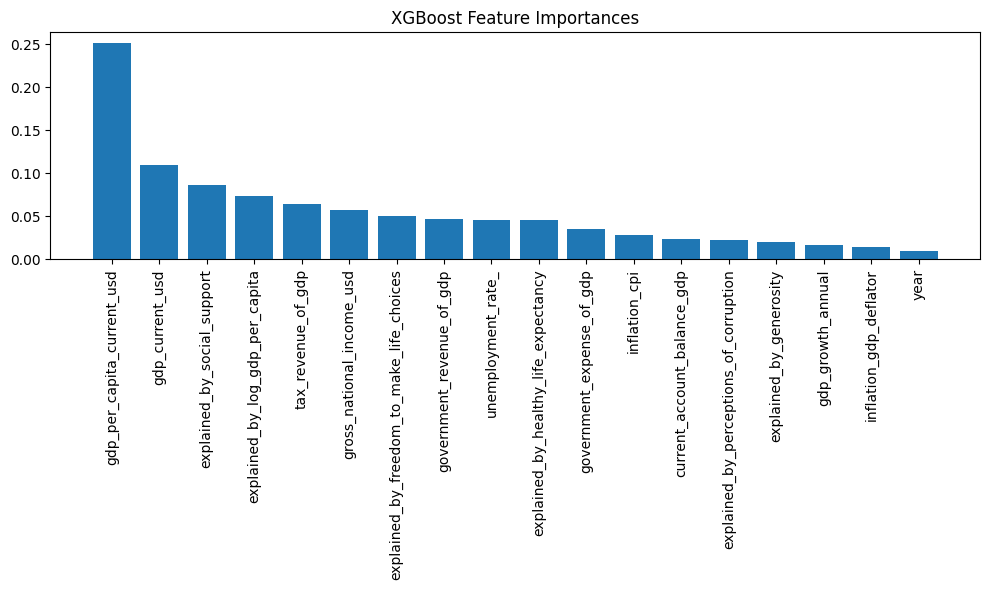

In [16]:
import matplotlib.pyplot as plt
import numpy as np

importances = model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
features = x.columns

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

Refaire le modèle sans les varaibles explained_by...

In [17]:
cols_to_remove = [col for col in x.columns if col.startswith("explained_by_")]
x_wb = x.drop(columns=cols_to_remove)

Refaire l'imputation

In [18]:
x_imputed = imputer.fit_transform(x_wb)
x_scaled = scaler.fit_transform(x_imputed)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

Entraîner à nouveau le XGBoost

In [19]:
model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)

Réévaluer le modèle

In [20]:
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 0.478780904829648
XGBoost R²: 0.8182418983038934


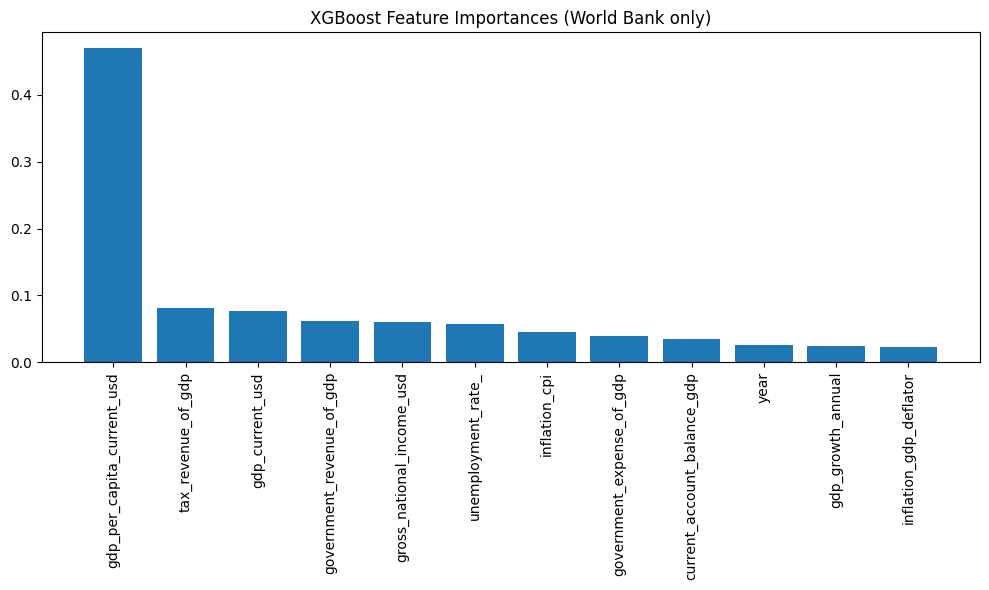

In [21]:
importances = model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
features = x_wb.columns

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title("XGBoost Feature Importances (World Bank only)")
plt.tight_layout()
plt.show()

Dans quelle mesure les variables de la World Bank expliquent le bonheur, indépendamment des variables du World Happiness Report ?

Retirer les variables richesse

In [22]:
wealth_vars = [
    "gdp_per_capita_current_usd",
    "gdp_current_usd",
    "gross_national_income_usd"
]

x_no_wealth = x_wb.drop(columns=wealth_vars)

Refaire pipeline

In [23]:
x_imputed = imputer.fit_transform(x_no_wealth)
x_scaled = scaler.fit_transform(x_imputed)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

Entraîner à nouveau

In [24]:
model_xgb.fit(x_train, y_train)
y_pred_xgb = model_xgb.predict(x_test)

Evaluer à nouveau

In [25]:
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 0.667768928291308
XGBoost R²: 0.6464323269448511


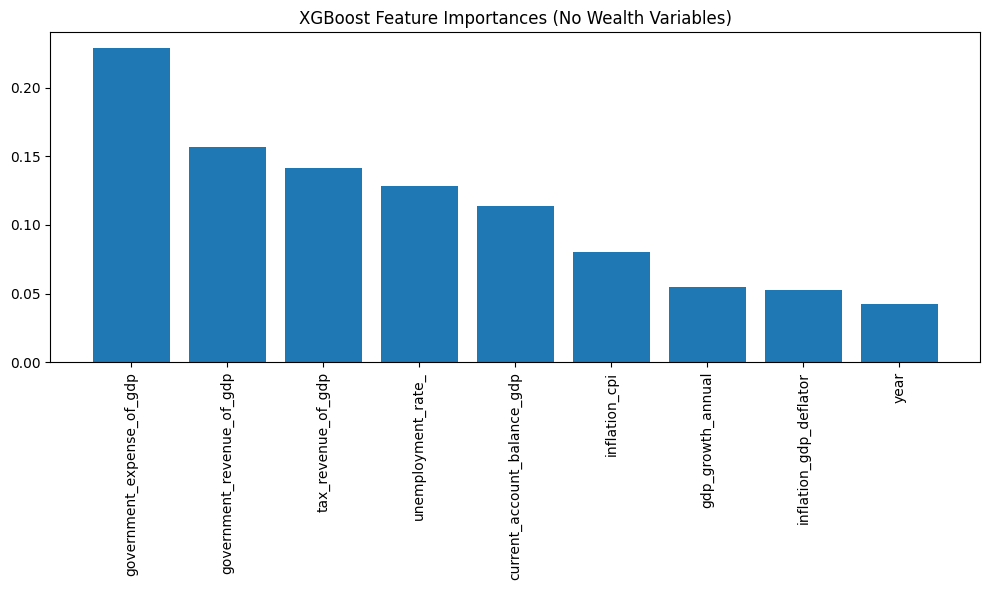

In [26]:
importances = model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
features = x_no_wealth.columns

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title("XGBoost Feature Importances (No Wealth Variables)")
plt.tight_layout()
plt.show()

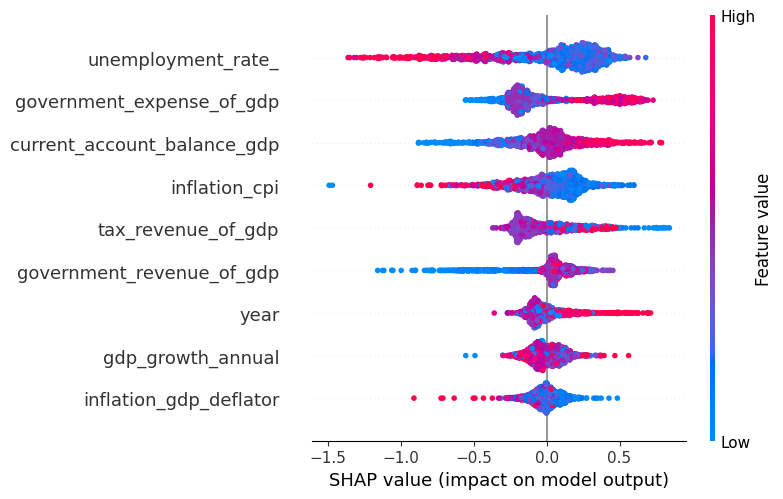

In [27]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(x_train)

shap.summary_plot(shap_values, x_train, feature_names=x_no_wealth.columns)

Analyse SHAP — Interprétation du modèle sans variables de richesse

L’analyse SHAP du modèle XGBoost (sans variables de richesse) révèle une structure très claire des déterminants du bonheur. Le graphique SHAP met en évidence l’impact de chaque variable sur les prédictions du modèle, en montrant à la fois l’importance globale et le sens de l’effet.

1. unemployment_rate_ — le facteur le plus déterminant
Le chômage est la variable la plus influente du modèle.
• 	Valeurs élevées → impact SHAP négatif
• 	Valeurs faibles → impact SHAP positif
Plus le chômage est élevé, plus le bonheur diminue.
Ce résultat est cohérent économiquement et sociologiquement.

2. government_expense_of_gdp — effet positif
Deuxième variable la plus influente.
• 	Dépenses publiques élevées → SHAP positif
• 	Dépenses publiques faibles → SHAP négatif
Les pays qui investissent davantage dans les services publics affichent un niveau de bonheur plus élevé.

3. current_account_balance_gdp — stabilité macroéconomique
• 	Excédent → SHAP positif
• 	Déficit → SHAP négatif
Les pays avec une balance courante saine tendent à être plus heureux.

4. inflation_cpi — effet négatif
• 	Inflation élevée → SHAP négatif
• 	Inflation faible → SHAP positif
L’inflation réduit le bien‑être, même sans tenir compte de la richesse.

5. tax_revenue_of_gdp — effet mixte
Effet non linéaire :
• 	Dans les pays stables : fiscalité élevée → services publics → effet positif
• 	Dans les pays pauvres : fiscalité élevée → charge perçue → effet négatif

6. government_revenue_of_gdp — similaire à tax_revenue
Effet dépendant du contexte économique du pays.

7. year — importance quasi nulle
Le bonheur n’a pas de tendance temporelle marquée dans le dataset.

8. gdp_growth_annual — très faible
La croissance économique n’améliore pas directement le bonheur.

9. inflation_gdp_deflator — négligeable
Le CPI est plus pertinent pour le bien‑être que le deflator.

Conclusion générale
L’analyse SHAP montre que, même en retirant les variables de richesse, le chômage, les dépenses publiques, la balance courante et l’inflation sont les principaux déterminants du bonheur. Les variables fiscales ont un effet plus complexe, dépendant du contexte économique du pays. La croissance économique et les variables temporelles ont un impact marginal. Ces résultats confirment que la stabilité économique et la qualité des services publics jouent un rôle majeur dans le bien‑être, indépendamment du niveau de richesse.

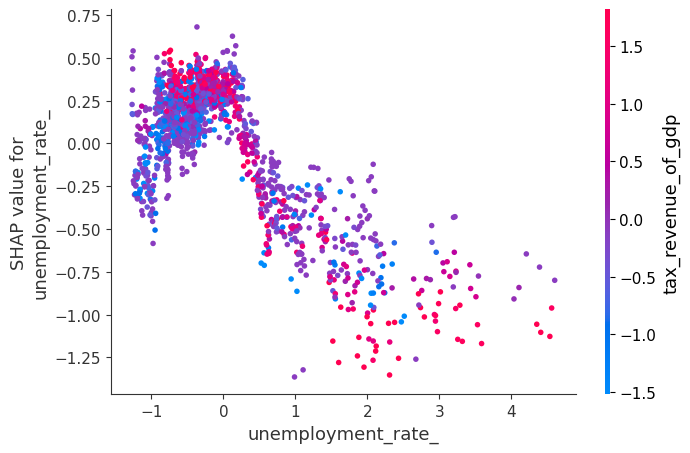

In [28]:
shap.dependence_plot("unemployment_rate_", shap_values, x_train, feature_names=x_no_wealth.columns)

L’interaction entre chômage et fiscalité montre que la fiscalité n’a un effet positif sur le bonheur que lorsque le chômage est faible. Dans les pays à faible chômage, une fiscalité élevée renforce l’effet positif sur le bonheur, probablement grâce à des services publics plus développés. En revanche, lorsque le chômage est élevé, même une fiscalité importante ne parvient pas à compenser l’impact négatif du chômage sur le bien‑être.

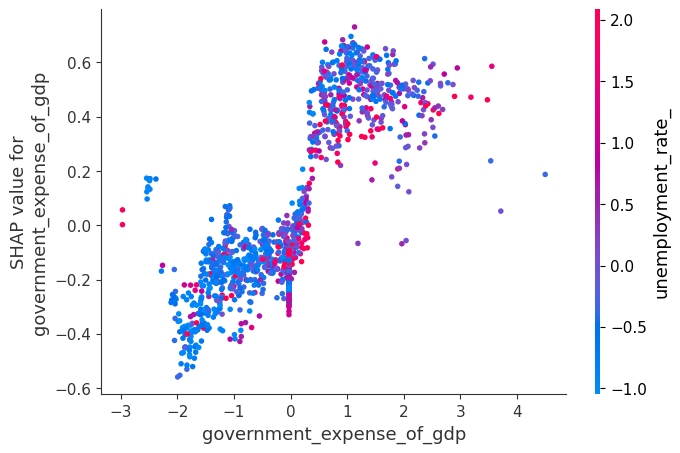

In [29]:
shap.dependence_plot(
    "government_expense_of_gdp",
    shap_values,
    x_train,
    feature_names=x_no_wealth.columns
)

Les dépenses publiques ont un effet positif sur le bonheur, particulièrement dans les pays où le chômage est faible. Lorsque les dépenses publiques dépassent environ 35 % du PIB, leur contribution au bonheur devient nettement positive, ce qui reflète l’impact des services publics, de la santé, de l’éducation et de la protection sociale. En revanche, lorsque le chômage est élevé, l’effet positif des dépenses publiques est atténué, suggérant que l’État-providence ne peut pas compenser entièrement l’insécurité économique liée au chômage.

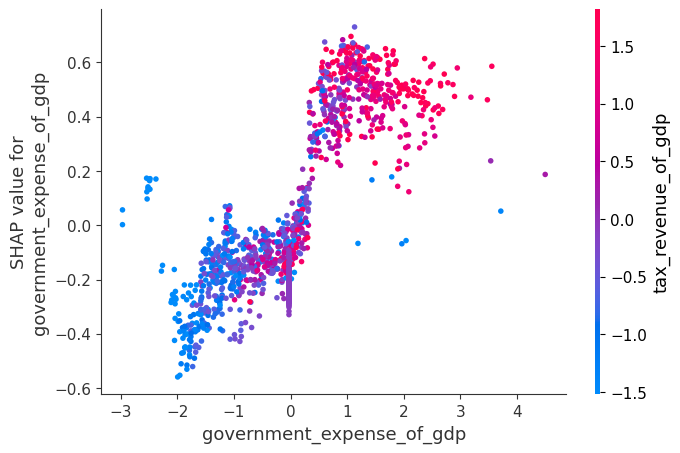

In [31]:
shap.dependence_plot(
    "government_expense_of_gdp",
    shap_values,
    x_train,
    feature_names=x_no_wealth.columns,
    interaction_index="tax_revenue_of_gdp"
)

Les dépenses publiques ont un effet positif sur le bonheur, particulièrement dans les pays où la fiscalité est élevée. Lorsque les dépenses publiques dépassent environ 35 % du PIB, leur contribution au bonheur devient nettement positive, ce qui reflète l’impact des services publics, de la santé, de l’éducation et de la protection sociale. L’interaction avec la fiscalité montre que les pays à forte taxation tirent davantage profit des dépenses publiques, suggérant que la qualité de l’État-providence joue un rôle majeur dans le bien‑être.

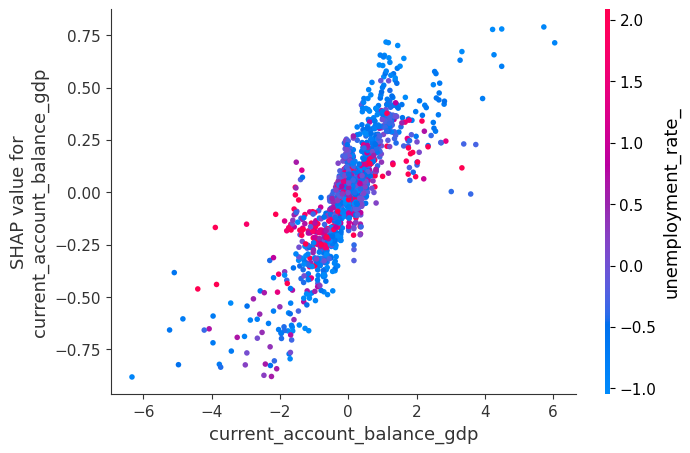

In [32]:
shap.dependence_plot(
    "current_account_balance_gdp",
    shap_values,
    x_train,
    feature_names=x_no_wealth.columns
)

La balance courante influence fortement le bonheur. Les pays en excédent présentent un effet SHAP positif, indiquant que la stabilité macroéconomique contribue au bien‑être. À l’inverse, les déficits courants sont associés à une contribution négative. L’interaction avec le chômage montre que cet effet est amplifié : les excédents profitent davantage aux pays à faible chômage, tandis que les déficits pénalisent fortement les pays à chômage élevé. Ces résultats suggèrent que la combinaison “stabilité externe + marché du travail solide” est un déterminant majeur du bonheur.

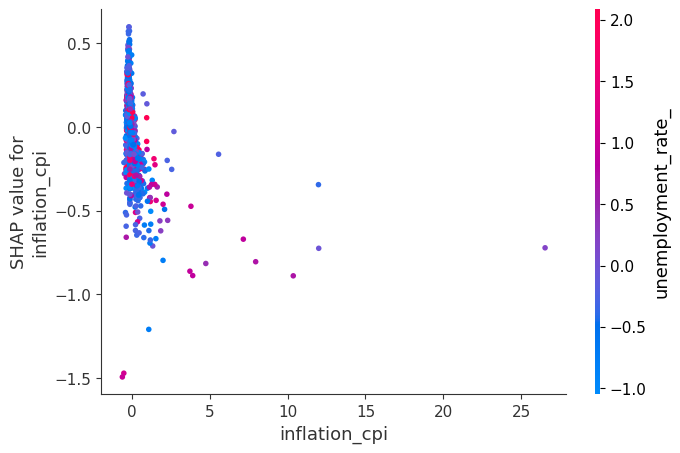

In [38]:
shap.dependence_plot(
    "inflation_cpi",
    shap_values,
    x_train,
    feature_names=x_no_wealth.columns,
    interaction_index="unemployment_rate_"
)

L’inflation a un effet fortement négatif sur le bonheur, particulièrement lorsqu’elle dépasse 10 %. L’interaction avec le chômage montre que l’impact de l’inflation est amplifié dans les pays où le chômage est élevé, ce qui reflète un phénomène de type “stagflation”. À l’inverse, les pays à faible chômage amortissent mieux l’effet négatif de l’inflation. Ces résultats soulignent que la stabilité des prix est un déterminant majeur du bien‑être, surtout lorsque le marché du travail est fragile.

In [63]:
year_target = 2023

idx = df.index[(df['country_name'] == "Costa Rica") & (df['year'] == year_target)][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    df_no_wealth.loc[idx]
)

En 2023, le Costa Rica présente un profil macroéconomique globalement favorable. L’inflation très faible, des recettes publiques élevées et un chômage modéré constituent les principaux facteurs qui tirent le score de bonheur vers le haut. Malgré des dépenses publiques importantes, le modèle prédit un niveau de bonheur nettement supérieur à la moyenne mondiale, reflétant la stabilité institutionnelle et la résilience économique du pays.

In [64]:
import shap
shap.initjs()

# --- Costa Rica ---
idx_cr = df.index[(df['country_name'] == "Costa Rica") & (df['year'] == 2023)][0]

display(shap.force_plot(
    explainer.expected_value,
    shap_values[idx_cr],
    df_no_wealth.loc[idx_cr]
))

# --- Finlande ---
idx_fi = df.index[(df['country_name'] == "Finland") & (df['year'] == 2023)][0]

display(shap.force_plot(
    explainer.expected_value,
    shap_values[idx_fi],
    df_no_wealth.loc[idx_fi]
))

In [65]:
df.columns

Index(['year', 'country_name', 'life_evaluation_3_year_average',
       'explained_by_log_gdp_per_capita', 'explained_by_social_support',
       'explained_by_healthy_life_expectancy',
       'explained_by_freedom_to_make_life_choices', 'explained_by_generosity',
       'explained_by_perceptions_of_corruption', 'key_iso3_year',
       'inflation_cpi', 'gdp_current_usd', 'gdp_per_capita_current_usd',
       'unemployment_rate_', 'inflation_gdp_deflator', 'gdp_growth_annual',
       'current_account_balance_gdp', 'government_expense_of_gdp',
       'government_revenue_of_gdp', 'tax_revenue_of_gdp',
       'gross_national_income_usd', 'country_code'],
      dtype='str')